In [43]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.metrics import accuracy_score, roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix

# Generate dataset

In [179]:
X, y = make_classification( n_samples=2502,
                            random_state=259202,
                            n_features=2,
                            n_informative=2,
                            n_redundant=0,
                            n_repeated=0,
                            class_sep=2)
Xm, ym = make_moons(n_samples=2502, random_state=259202)
Xb ,yb = make_blobs(n_samples=2502, random_state=259202, n_features=2, centers=5, cluster_std=0.8)

In [180]:
X.shape, y.shape, Xm.shape, ym.shape, Xb.shape, yb.shape

((2502, 2), (2502,), (2502, 2), (2502,), (2502, 2), (2502,))

In [181]:
print(set(yb))
yb = np.where(yb == 3, 0, yb)
yb = np.where(yb == 4, 1, yb)
yb = np.where(yb == 5, 2, yb)
print(set(yb))

{0, 1, 2, 3, 4}
{0, 1, 2}


In [182]:
def plot_data(X,y, title=""):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
    plt.title(title)
    plt.show()

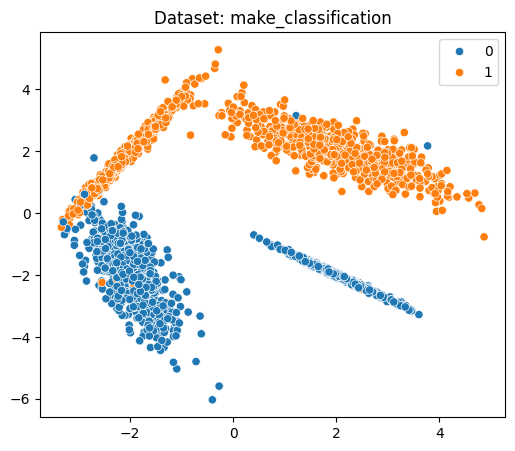

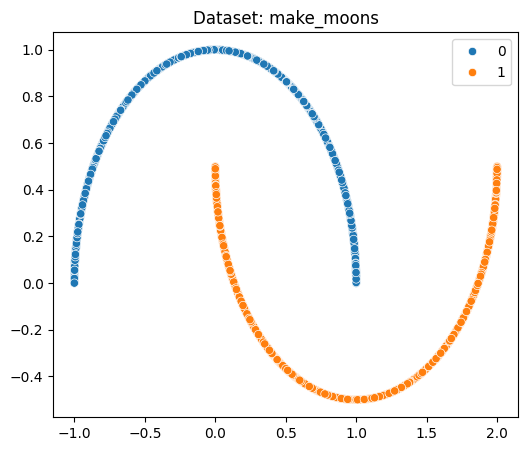

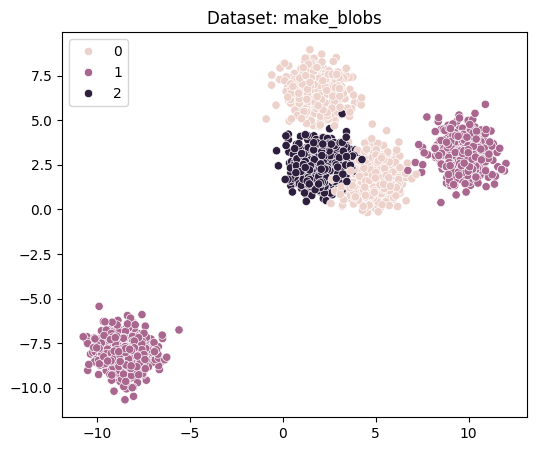

In [183]:
plot_data(X,y,"Dataset: make_classification")
plot_data(Xm,ym,"Dataset: make_moons")
plot_data(Xb,yb,"Dataset: make_blobs")

In [184]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=295202)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, random_state=295202)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, random_state=295202)

In [193]:
def plot_decision_boundary(X, y, model, custom=False, title=""):
    h = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    pts = np.c_[xx.ravel(), yy.ravel()]

    if custom:
        # predict_impl_svm returns (pred, score)
        # _, Z = predict_impl_svm(model, pts)   
        pass
    else:
        Z = model.predict(pts)

    # reshape the result back into the grid
    Z = Z.reshape(xx.shape)

    # plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3)
    
    # plot decision line boundary
    plt.contour(xx, yy, Z, colors='k', linewidths=1)
    
    # data points
    scatter = plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
    
    plt.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    plt.title(title)
    plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.show()

# Implemented Decision Tree Classifier

In [ ]:
# brak potrzeby normalizacji - sa ify

# Sklearn DecisionTreeClassifier

In [186]:
datasets = {
    'classification': (X_train, y_train, X_test, y_test),
    'moons': (Xm_train, ym_train, Xm_test, ym_test),
    'blobs': (Xb_train, yb_train, Xb_test, yb_test)
}

all_results = []
for ds_name, (X_tr, y_tr, X_te, y_te) in datasets.items():

    n_features = X_tr.shape[1]
    n_clusters = len(np.unique(y_tr))
    depths = [None, n_features, n_clusters]
    
    for depth in set(depths):
        clf = DecisionTreeClassifier(random_state=259202, max_depth=depth)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        acc = accuracy_score(y_te, y_pred)
        
        all_results.append({
            'dataset': ds_name,
            'depth': depth,
            'accuracy': acc,
            'model': clf
        })

results_df = pd.DataFrame(all_results)

In [187]:
results_df

,dataset,depth,accuracy,model
0,classification,NaN,0.976038,DecisionTreeClassifier(random_state=259202)
1,classification,2.0,0.993610,"DecisionTreeClassifier(max_depth=2, random_sta..."
2,moons,NaN,0.996805,DecisionTreeClassifier(random_state=259202)
3,moons,2.0,0.923323,"DecisionTreeClassifier(max_depth=2, random_sta..."
4,blobs,NaN,0.966454,DecisionTreeClassifier(random_state=259202)
5,blobs,2.0,0.797125,"DecisionTreeClassifier(max_depth=2, random_sta..."
6,blobs,3.0,0.797125,"DecisionTreeClassifier(max_depth=3, random_sta..."


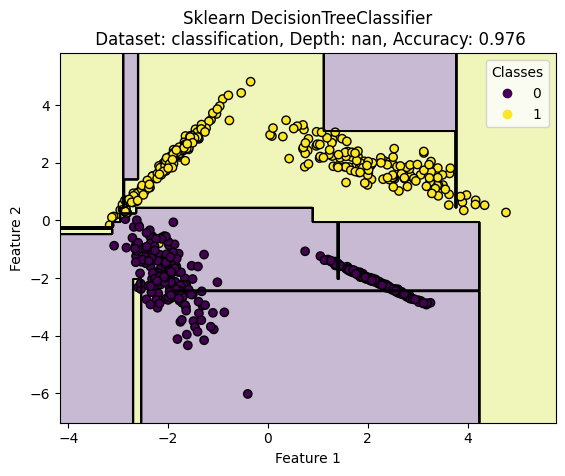

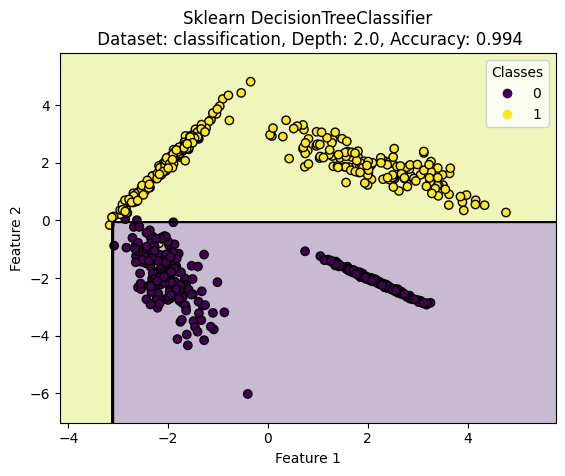

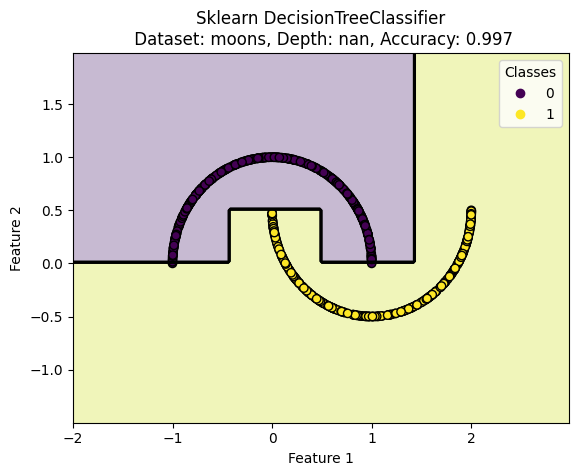

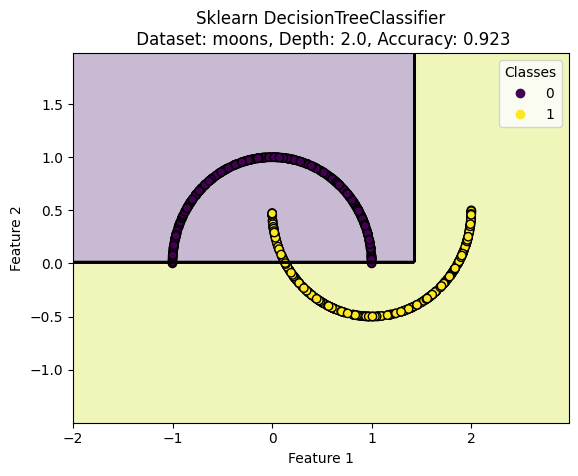

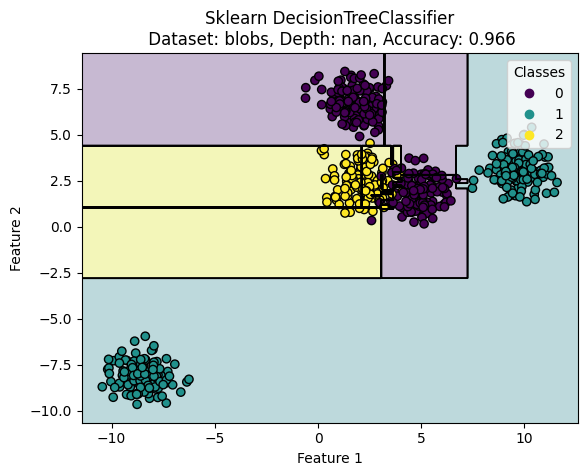

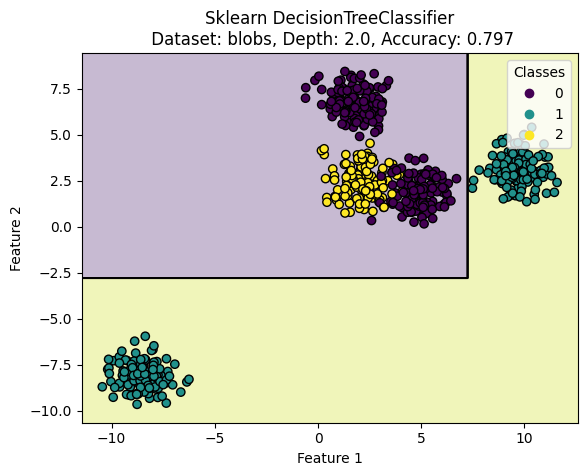

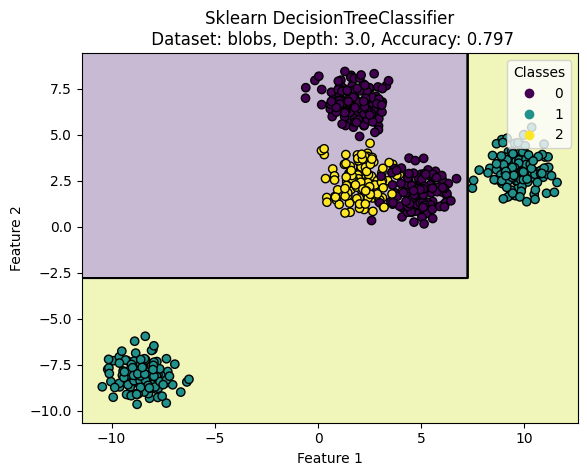

In [194]:
for _, result in results_df.iterrows():
    ds_name = result['dataset']
    depth = result['depth']
    model = result['model']
    _, _, X_test, y_test = datasets[ds_name]
    
    title = f"Sklearn DecisionTreeClassifier\n Dataset: {ds_name}, Depth: {depth}, Accuracy: {result['accuracy']:.3f}"
    
    plot_decision_boundary(X_test, y_test, model, custom=False, title=title)